In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:/Skill Graph/Data/processed/skill_matrix.csv")
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,powerbi,pandas,numpy,r,spark,aws,machine learning,statistics,data visualization,hadoop
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,...,0,0,0,1,0,1,0,1,0,0
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),overview\n\nprovides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,...,0,0,0,1,0,0,0,1,0,0
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),we’re looking for a senior data analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,...,0,0,0,1,0,0,0,0,1,0
3,Data Analyst,$37K-$66K (Glassdoor est.),requisition numberrr-0001939\nremote:yes\nwe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,...,1,0,0,1,0,1,0,0,1,0
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),about fanduel group\n\nfanduel group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,...,0,0,0,1,0,0,0,0,0,0


In [3]:
df["Salary Estimate"] = df["Salary Estimate"].str.replace(r"\(.*\)", "", regex=True)
df["Salary Estimate"] = df["Salary Estimate"].str.replace("K", "")
df["Salary Estimate"] = df["Salary Estimate"].str.replace("$", "")

In [4]:

salary_split = df["Salary Estimate"].str.split("-", expand=True)

df["salary_min"] = pd.to_numeric(salary_split[0], errors="coerce")
df["salary_max"] = pd.to_numeric(salary_split[1], errors="coerce")

df["salary_avg"] = (df["salary_min"] + df["salary_max"]) / 2

In [5]:
skills = [
    "python","sql","excel","tableau","power bi",
    "pandas","numpy","r","spark","aws",
    "machine learning","statistics","data visualization","hadoop"
]

In [6]:
salary_by_skill = {}

for skill in skills:
    salary_by_skill[skill] = df[df[skill] == 1]["salary_avg"].mean()

salary_df = pd.DataFrame.from_dict(
    salary_by_skill,
    orient="index",
    columns=["Average Salary"]
)

salary_df = salary_df.sort_values(
    by="Average Salary",
    ascending=False
)

salary_df

,Average Salary
python,74.733909
tableau,74.243548
hadoop,74.220588
machine learning,73.977778
statistics,72.138544
r,72.138444
data visualization,72.113569
spark,72.073034
sql,71.793439
excel,71.663462


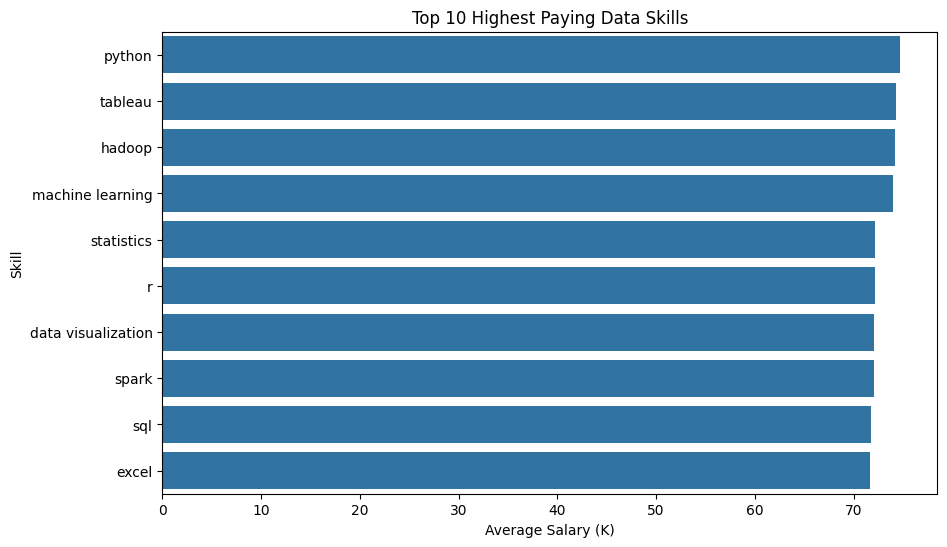

In [7]:
top_salary = salary_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Average Salary",
    y=top_salary.index,
    data=top_salary
)

plt.title("Top 10 Highest Paying Data Skills")
plt.xlabel("Average Salary (K)")
plt.ylabel("Skill")

plt.savefig("D:/Skill Graph/visualization/salary_vs_skill.png")

plt.show()